In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from scipy.io import loadmat
import matplotlib.pyplot as plt
# Enable cuDNN
tf.keras.backend.set_image_data_format('channels_first')

In [11]:
# Load data
z1 = loadmat('z1.mat')['z1']
z1 = np.array(z1)

# Split data into inputs and outputs
X = z1[:, :6]
Y = z1[:, 6:]

# Normalize joint angles to be between -1 and 1
Y = Y / np.pi
print(Y)

# Shuffle data
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
Y = Y[indices]

[[-0.5        -0.92307692  0.         -0.5         1.         -0.21153846]
 [-0.5        -0.92307692  0.         -0.5         1.         -0.17307692]
 [-0.5        -0.92307692  0.         -0.5         1.         -0.13461538]
 ...
 [ 0.11538462 -0.07692308  0.          0.5         1.          0.17307692]
 [ 0.11538462 -0.07692308  0.          0.5         1.          0.21153846]
 [ 0.11538462 -0.07692308  0.          0.5         1.          0.25      ]]


In [22]:
def train_validate_test_split(x, y, train_size=0.7, validate_size=0.15, test_size=0.15, random_state=None):
    if validate_size + test_size >= 1.0:
        raise ValueError("The sum of validate_size and test_size should be less than 1.0.")
    
    x_train, x_temp, y_train, y_temp = train_test_split(x, y, train_size=train_size, random_state=random_state)
    
    remaining = 1.0 - train_size
    validate_ratio = validate_size / (validate_size + test_size)
    test_ratio = test_size / (validate_size + test_size)
    
    x_validate, x_test, y_validate, y_test = train_test_split(x_temp, y_temp, train_size=validate_ratio, test_size=test_ratio, random_state=random_state)
    
    return x_train, x_validate, x_test, y_train, y_validate, y_test

# Train-validate-test split
X_train, X_validate ,X_test, Y_train, Y_validate ,Y_test = train_validate_test_split(X, Y , train_size=0.7, validate_size=0.15, test_size=0.15, random_state=42)
# Create a fully connected neural network model
model = keras.Sequential([
        keras.layers.Dense(6),
        keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
         keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(6)  # Output layer with 6 neurons (x, y, z, a, b, c)
])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint("model_z1.h5", save_best_only=True, monitor='val_loss', mode='min')

# Learning rate scheduler
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mean_squared_error'])

# Train the model
history = model.fit(X_train, Y_train, epochs=1000, validation_data=(X_validate, Y_validate),
                    batch_size=400, shuffle=True, callbacks=[early_stopping, model_checkpoint])

Epoch 1/1000
111/111 [==============================] - 4s 25ms/step - loss: 0.3555 - mean_squared_error: 0.3555 - val_loss: 0.0124 - val_mean_squared_error: 0.0124
Epoch 2/1000
111/111 [==============================] - 2s 19ms/step - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0096 - val_mean_squared_error: 0.0096
Epoch 3/1000
111/111 [==============================] - 2s 20ms/step - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0087 - val_mean_squared_error: 0.0087
Epoch 4/1000
111/111 [==============================] - 2s 19ms/step - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0079 - val_mean_squared_error: 0.0079
Epoch 5/1000
111/111 [==============================] - 2s 19ms/step - loss: 0.0071 - mean_squared_error: 0.0071 - val_loss: 0.0067 - val_mean_squared_error: 0.0067
Epoch 6/1000
111/111 [==============================] - 2s 18ms/step - loss: 0.0068 - mean_squared_error: 0.0068 - val_loss: 0.0068 - val_mean_squared_error: 0.0068
Epoch 7/10

111/111 [==============================] - 2s 16ms/step - loss: 0.0024 - mean_squared_error: 0.0024 - val_loss: 0.0033 - val_mean_squared_error: 0.0033
Epoch 51/1000
111/111 [==============================] - 2s 16ms/step - loss: 0.0027 - mean_squared_error: 0.0027 - val_loss: 0.0026 - val_mean_squared_error: 0.0026
Epoch 52/1000
111/111 [==============================] - 2s 16ms/step - loss: 0.0024 - mean_squared_error: 0.0024 - val_loss: 0.0026 - val_mean_squared_error: 0.0026
Epoch 53/1000
111/111 [==============================] - 2s 17ms/step - loss: 0.0023 - mean_squared_error: 0.0023 - val_loss: 0.0037 - val_mean_squared_error: 0.0037
Epoch 54/1000
111/111 [==============================] - 2s 16ms/step - loss: 0.0024 - mean_squared_error: 0.0024 - val_loss: 0.0022 - val_mean_squared_error: 0.0022
Epoch 55/1000
111/111 [==============================] - 2s 16ms/step - loss: 0.0022 - mean_squared_error: 0.0022 - val_loss: 0.0025 - val_mean_squared_error: 0.0025
Epoch 56/1000
111/

111/111 [==============================] - 2s 16ms/step - loss: 0.0014 - mean_squared_error: 0.0014 - val_loss: 0.0015 - val_mean_squared_error: 0.0015
Epoch 100/1000
111/111 [==============================] - 2s 16ms/step - loss: 0.0013 - mean_squared_error: 0.0013 - val_loss: 0.0027 - val_mean_squared_error: 0.0027


In [23]:
# Evaluate on the test set
test_loss = model.evaluate(X_test, Y_test)
print(f"Test Loss: {test_loss[0]}, Test MSE: {test_loss[1]}")

297/297 [==============================] - 2s 6ms/step - loss: 0.0012 - mean_squared_error: 0.0012
Test Loss: 0.0012263557873666286, Test MSE: 0.0012263557873666286


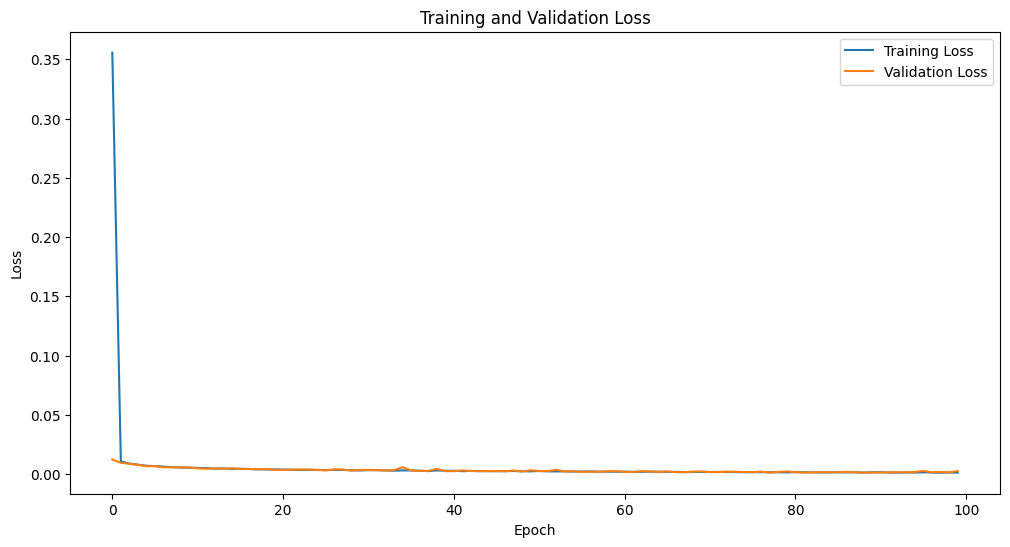

In [24]:
# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

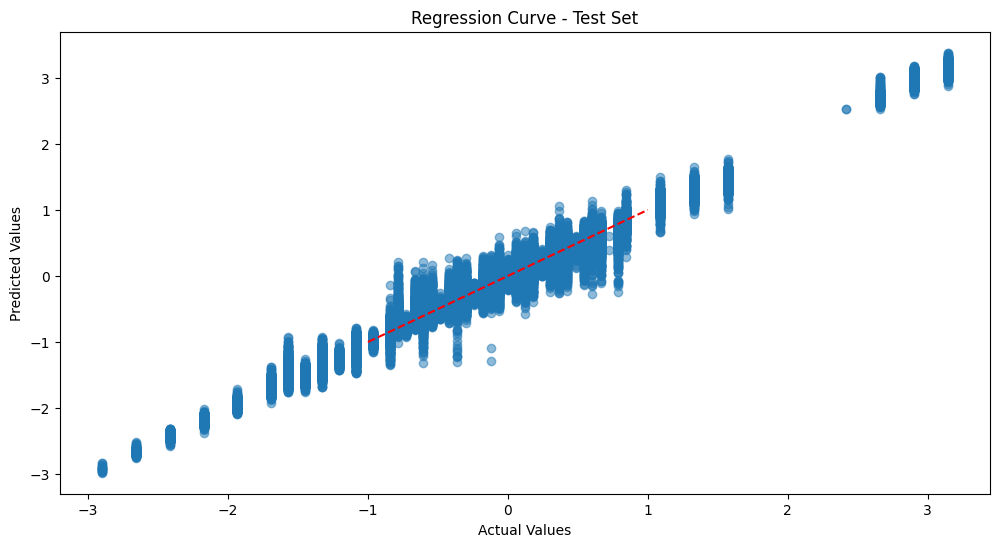

In [25]:
# Plot regression curve for test set
test_predictions = model.predict(X_test) * np.pi  # Use 'model' instead of 'best_model'
plt.figure(figsize=(12, 6))
plt.scatter(Y_test * np.pi, test_predictions, alpha=0.5)
plt.plot([-1, 1], [-1, 1], color='red', linestyle='--')
plt.title('Regression Curve - Test Set')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

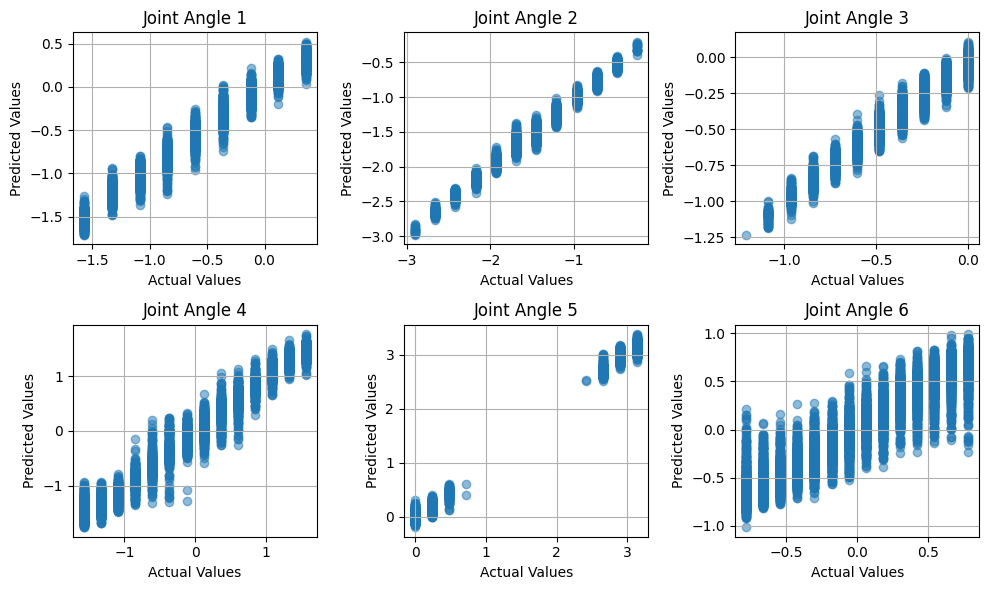

In [26]:
# Make predictions on the test set
predictions = model.predict(X_test)

# Inverse normalize the joint angles for better interpretation
predictions = predictions * np.pi
Y_test = Y_test * np.pi
# Plotting predicted vs. actual values
plt.figure(figsize=(10, 6))
for i in range(6):  # Assuming you have 6 joint angles
    plt.subplot(2, 3, i + 1)
    plt.scatter(Y_test[:, i], predictions[:, i], alpha=0.5)
    plt.title(f'Joint Angle {i + 1}')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)

plt.tight_layout()
plt.show()

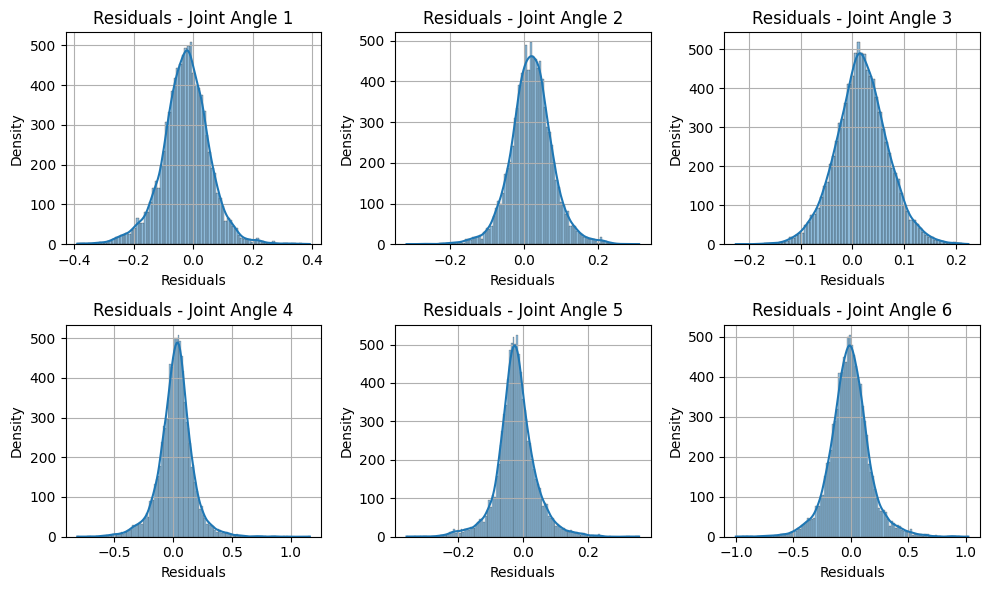

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
# Residual plots
residuals = Y_test - predictions

plt.figure(figsize=(10, 6))
for i in range(6):  # Assuming you have 6 joint angles
    plt.subplot(2, 3, i + 1)
    sns.histplot(residuals[:, i], kde=True)
    plt.title(f'Residuals - Joint Angle {i + 1}')
    plt.xlabel('Residuals')
    plt.ylabel('Density')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [3]:
# Load the best model for predictions
best_model = tf.keras.models.load_model("model_z1.h5")

# Test the loaded model with [10, 20, 30, 40, 50, 60]
test_inputs = np.array([[194.5, 161.4, 283.1, 0, -90, 38.07]])
predictions = best_model.predict(test_inputs) * np.pi

print("Predictions for test inputs:")
print(predictions)

Predictions for test inputs:
[[-0.4617082  -2.0159917  -0.29939523 -1.0808696   2.9795418  -0.14731315]]
